# Monte Carlo European Call Option Pricing - Example Usage

This notebook demonstrates how to use the package and shows example parameter settings and outputs.

In [1]:
from my_project.__main__ import (
    monte_carlo_call_price_stats,
    black_scholes_call_price
)

In [2]:
s0 = 100
k = 110
t = 1
r = 0.05
sigma = 0.2
n_sim = 10000

In [3]:
mc_price, standard_error, ci_lower, ci_upper = monte_carlo_call_price_stats(
    s0, k, t, r, sigma, n_sim
)

bs_price = black_scholes_call_price(s0, k, t, r, sigma)

abs_error = abs(mc_price - bs_price)

print("Monte Carlo Price:", mc_price)
print("Black-Scholes Price:", bs_price)
print("Absolute Error:", abs_error)
print("Standard Error:", standard_error)
print("95% CI:", (ci_lower, ci_upper))

Monte Carlo Price: 6.03306191155554
Black-Scholes Price: 6.040088129724225
Absolute Error: 0.00702621816868465
Standard Error: 0.11604842875255772
95% CI: (5.805606991200527, 6.260516831910554)


## Example command line usage

python -m my_project 100 110 1 0.05 0.2 10000

In [4]:
%pip install matplotlib ipykernel


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


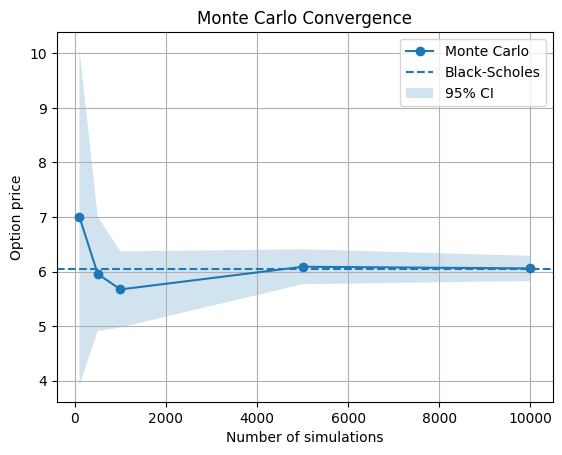

In [7]:
import matplotlib.pyplot as plt

n_values = [100, 500, 1000, 5000, 10000]
mc_prices = []
lower_bounds = []
upper_bounds = []

for n in n_values:
    price, se, ci_low, ci_up = monte_carlo_call_price_stats(s0, k, t, r, sigma, n)
    mc_prices.append(price)
    lower_bounds.append(ci_low)
    upper_bounds.append(ci_up)

plt.plot(n_values, mc_prices, marker='o', label='Monte Carlo')
plt.axhline(bs_price, linestyle='--', label='Black-Scholes')

plt.fill_between(n_values, lower_bounds, upper_bounds, alpha=0.2, label='95% CI')

plt.xlabel('Number of simulations')
plt.ylabel('Option price')
plt.title('Monte Carlo Convergence')
plt.legend()
plt.grid()

plt.show()

## Interpretation

The Monte Carlo estimate converges towards the Black-Scholes analytical solution as the number of simulations increases.

The standard error decreases with more simulations, indicating improved accuracy.

The confidence interval provides a statistical range for the estimated option price.